# Experiment 2: Heterogenous Tissue
**Drug Modeled:** Gefitinib

**Condition Tested:** Diffusion through dense, heterogenous tumor tissue

**Research Question:** How does tissue structure influence drug delivery?

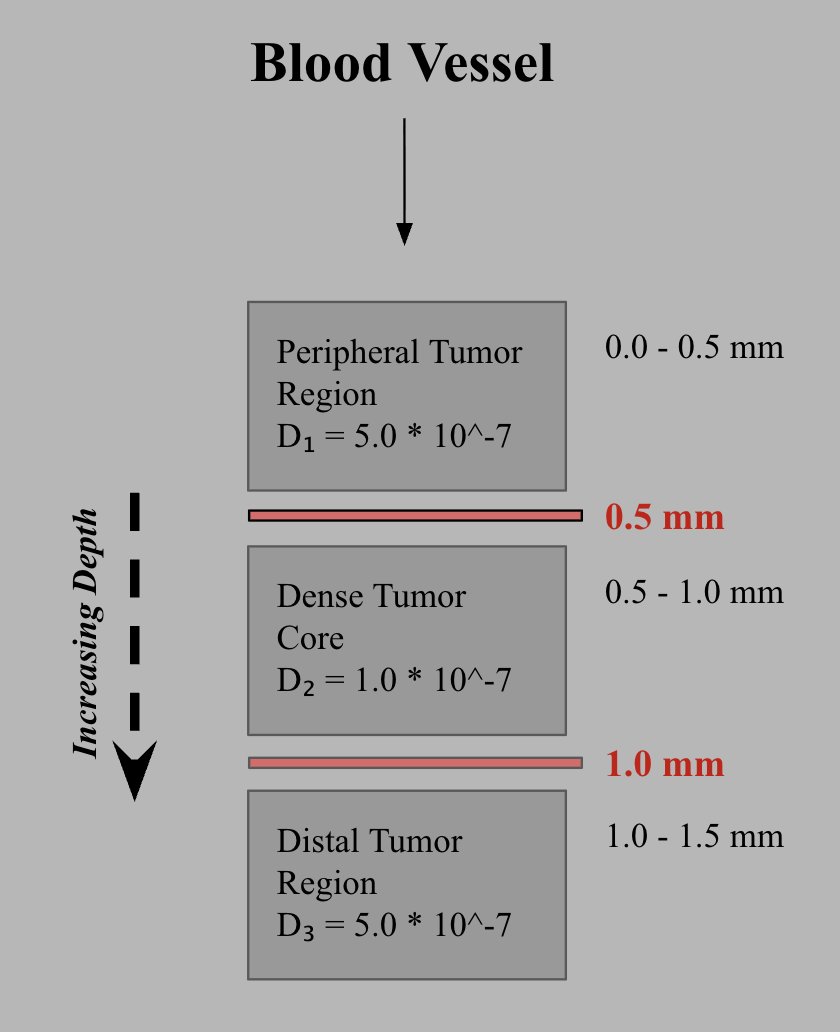

In [15]:
from IPython.display import Image

Image('figures/exp02_layered_tissue_schematic.png', width = 500)

## Figure 2A

**Figure 2A.** Schematic representation of the heterogeneous tissue model governing this experiment.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
D = 5e-7            # cm^2 /s

# Normalized source concentration
# Relative concentration used to study spatial gradients
C0 = 1.0            # arbitrary units

# Tissue depth range
# 0-2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)       # cm

# Single time point
# 1 hour after drug exposure
t = 3600            # seconds

In [17]:
import numpy as np

# Analytical Solution to Fick's Second Law

# Fundamental solution of the 1D diffusion equation

# Represents spatial redistribution of drug from an initial source

normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gefitinib concentration profile as a function of depth

C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

ny = 100

C_heatmap = np.tile(C, (ny, 1))

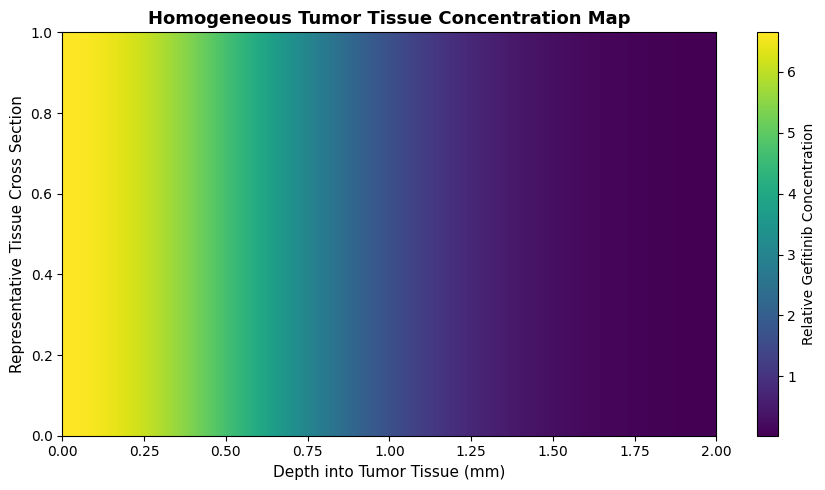

In [18]:
import os
os.makedirs('figures', exist_ok=True)

# Plot

fig1, ax1 = plt.subplots(figsize=(9, 5))

im = ax1.imshow(
    C_heatmap,
    aspect='auto',
    cmap='viridis',
    origin='lower',
    extent=[0, x.max() * 10, 0, 1]
)

# Labels and formatting
ax1.set_title(
    'Homogeneous Tumor Tissue Concentration Map',
    fontsize=13,
    fontweight='bold'
)

ax1.set_xlabel(
    'Depth into Tumor Tissue (mm)',
    fontsize=11
)

ax1.set_ylabel(
    'Representative Tissue Cross Section',
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('Relative Gefitinib Concentration')

plt.tight_layout()

plt.savefig(
    'figures/exp02_homogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Figure 2B

**Figure 2B.** Simulated gefitinib concentration distribution in homogeneous tumor tissue. Drug concentration decreases smoothly with increasing depth, producing a continuous concentration gradient in the absence of structural heterogeneity.

### Observations

* Smooth, monotonic decrease in gefitinib concentration with increasing distance from the source boundary
* Gradient appears consistent and symmetric through the entire cross-section
* No abrupt changes or discontinuities

### Interpretation

This behavior is consistent with classical diffusion dynamics in a homogeneous medium, where spatial transport is governed solely by a constant diffusion coefficient. The absence of structural variation means there are no spatial anomolies to the flux, resulting in predictable smoothing of the concentration field over time. Drug availability is therefore solely a function of distance from the source and time elapsed.

### Discussion

This result provides a baseline reference for drug transport in the absence of tissue heterogeneity. It represents an idealized condition in which spatial pharmacokinetics are governed only by passive diffusion. However, this scenario is biologically limited, as real tumor microenvironments exhibit variable extracellular matrix density, vascular irregularity, and cellular crowding. As such, while this model establishes fundamental diffusion behavior, it likely overestimates drug penetration uniformity in vivo and underestimates local variability in therapeutic exposure.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

In [20]:
# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (2 * D[i-1] * D[i]) / (D[i-1] + D[i])
        D_right = (2 * D[i] * D[i+1]) / (D[i] + D[i+1])

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

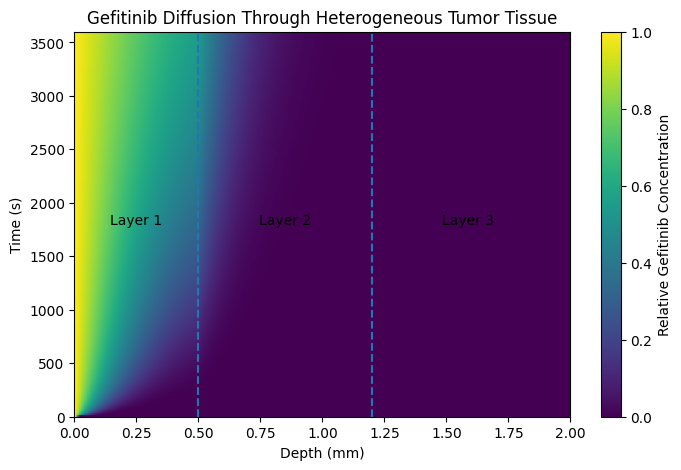

In [21]:
C_heatmap = np.array(saved_profiles)

plt.figure(figsize=(8, 5))

plt.imshow(

    C_heatmap,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

plt.colorbar(label='Relative Gefitinib Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp02_heterogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 2C

**Figure 2C.** Spatial–temporal heatmap of gefitinib diffusion through heterogeneous tumor tissue. Vertical dashed lines indicate transitions between tissue layers with different diffusion coefficients. The low-diffusivity middle layer acts as a transport barrier, slowing drug penetration and producing reduced concentrations at greater depths.

### Observations

* Non-uniform diffusion patterns as gefitinib propagates through heterogeneous tissue
* Distinct regions of altered transport behavior are visiblep
* The central low-diffusivity layer significantly slows drug progression, producing a visible delay in downstream concentration increase

### Interpretation

The introduction of spatially varying diffusion coefficients produces asymmetric transport dynamics. The low-diffusivity region acts as a partial barrier to molecular flux, effectively reducing the local rate of diffusion and altering concentration propagation speed. This creates spatial gradients that are no longer solely distance-dependent but are instead modulated by tissue architecture. The observed upstream accumulation reflects transient impedance of flux across the heterogeneous boundary.

### Discussion

These results demonstrate that structural heterogeneity within tumor tissue is sufficient to significantly reshape drug transport dynamics. Even in the absence of changes in drug chemistry or dosing, spatial variations in extracellular properties can generate pronounced differences in local drug availability. This suggests that therapeutic exposure is not solely a function of administered dose, but is strongly mediated by microenvironmental architecture. Consequently, regions of low diffusivity may contribute to pharmacological shielding, potentially enabling survival niches for resistant cellular subpopulations.

In [22]:
import numpy as np

# Spatial domain
L = 0.2                      # cm (2 mm tissue depth)
nx = 200
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Time domain
T = 3600                     # total simulation time (s)
nt = 5000
dt = T / nt

# Diffusion coefficient (homogeneous tissue)
D = 5e-7                     # cm^2/s (constant everywhere)

# Initial condition
C = np.zeros(nx)

C[0] = 1.0                   # constant source at vessel boundary

In [23]:
import numpy as np

# ---------------------- Homogeneous Tissue Diffusion ----------------------

saved_profiles_homogenous = []
save_every = 50

for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):

        # Flux-based diffusion
        J_left = -D * (C[i] - C[i-1]) / dx
        J_right = -D * (C[i+1] - C[i]) / dx

        # Update equation
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C_new[0] = 1.0
    C_new[-1] = C_new[-2]

    C = C_new

    if (t % save_every == 0):
        saved_profiles_homogenous.append(C)

# ---------------------- Heterogenous Tissue Diffusion ----------------------

saved_profiles_heterogenous = []

# Varying diffusitivies (cm^2 /s)
D2 = 1e-7
D3 = 5e-7

# Boundary values (cm)
boundary_1 = 0.05       # 0.5 mm
boundary_2 = 0.12       # 1.2 mm

# Building the diffusitivity profile
D_heterogenous = np.full(nx, D)

D_heterogenous[x >= boundary_1] = D2
D_heterogenous[x >= boundary_2] = D3


for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):

        # Diffusitivity values
        D_left = (2 * D_heterogenous[i-1] * D_heterogenous[i]) / (D_heterogenous[i-1] + D_heterogenous[i])
        D_right = (2 * D_heterogenous[i] * D_heterogenous[i+1]) / (D_heterogenous[i] + D_heterogenous[i+1])

        # Flux-based diffusion
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C_new[0] = 1.0
    C_new[-1] = C_new[-2]

    C = C_new

    if (t % save_every) == 0:
        saved_profiles_heterogenous.append(C.copy())

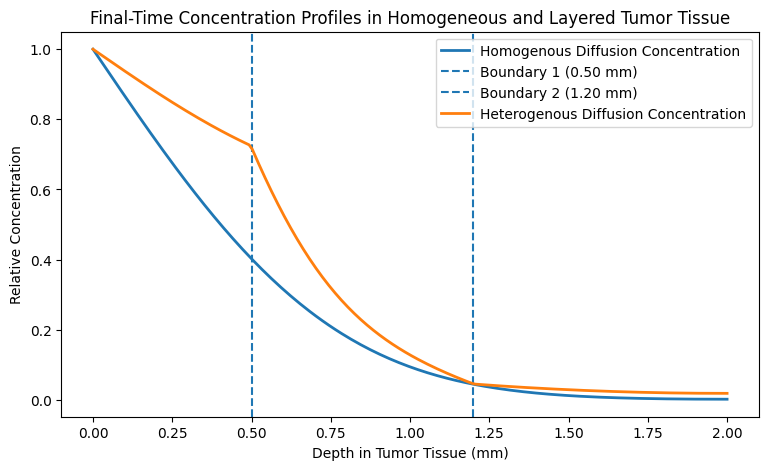

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Plot

C_homogenous = np.array(saved_profiles_homogenous)
C_heterogenous = np.array(saved_profiles_heterogenous)


# Final homogenous concentration profile
homo_final = C_homogenous[-1]

# Final heterogenous concentration profile
layer_final = C_heterogenous[-1]

fig2, ax2 = plt.subplots(figsize = (9,5))

ax2.plot(x * 10, homo_final, linewidth = 2, label = 'Homogenous Diffusion Concentration')

ax2.axvline(boundary_1 * 10, linestyle = '--', label = 'Boundary 1 (0.50 mm)')

ax2.axvline(boundary_2 * 10, linestyle = '--', label = 'Boundary 2 (1.20 mm)')

ax2.plot(x * 10, layer_final, linewidth = 2, label = 'Heterogenous Diffusion Concentration')

plt.ylabel('Relative Concentration')
plt.xlabel('Depth in Tumor Tissue (mm)')

plt.title('Final-Time Concentration Profiles in Homogeneous and Layered Tumor Tissue')

plt.legend()

plt.savefig(
    'figures/exp02_concentration_profile_comparison.png',
    dpi=150,
    bbox_inches='tight'
)



## Figure 2D

**Figure 2D.** Comparison of final-time gefitinib concentration profiles in homogeneous and layered tumor tissue. Vertical dashed lines indicate transitions between tissue layers with different diffusion coefficients. The low-diffusivity middle layer alters drug transport by slowing diffusion and causing local accumulation upstream of the tissue boundary. As a result, the heterogeneous tissue profile deviates substantially from the homogeneous case, demonstrating how spatial variations in tissue structure can reshape intratumoral drug distribution even under identical source conditions.

### Observations

* Clear divergence in final-time concentration profiles
* Homogeneous system maintains a smooth decay profile
* Heterogeneous system exhibits localized deviations in concentration corresponding to tissue layer boundaries
* Low-diffusivity region results in increased concentration upstream and reduced penetration downstream

### Interpretation

The differences between the two profiles indicate that spatial structure directly modulates steady-state drug distribution. The heterogeneous tissue introduces effective resistance to transport, altering both the magnitude and spatial decay rate of the concentration field. The accumulation effect upstream of the barrier reflects flux conservation under constrained diffusion, while reduced distal concentrations indicate impaired penetration efficiency. This confirms that diffusion alone is insufficient to describe intratumoral pharmacokinetics in structured environments.

### Discussion

This comparison highlights the critical role of tissue architecture in shaping intratumoral drug exposure. Under identical source conditions, structural heterogeneity produces substantially different pharmacological landscapes, potentially leading to spatially variable therapeutic efficacy. Such variability has direct implications for treatment outcomes, as regions receiving sub-therapeutic drug concentrations may act as reservoirs for continued proliferation or resistance development. These findings motivate the inclusion of spatially resolved tissue properties in predictive models of drug delivery and response, particularly in solid tumors where microenvironmental heterogeneity is pronounced.

## Experiment 2 Summary

Experiment 2 investigates how spatial variations in tumor tissue structure alter the intratumoral distribution of gefitinib under identical vascular input conditions. The system is defined as a one-dimensional layered tumor spanning 0–2 mm in depth, supplied by a blood vessel at the boundary. The tissue is composed of three distinct regions with differing diffusion coefficients: an initial outer layer (D₁ = 5 × 10⁻⁷), a central dense barrier layer (D₂ = 1 × 10⁻⁷), and an inner tumor layer (D₃ = 5 × 10⁻⁷). This configuration is used to model how extracellular matrix density and structural heterogeneity influence drug penetration independent of pharmacological parameters.

Across Figures 2B–2D, the results demonstrate a clear divergence between homogeneous and heterogeneous transport regimes. In the homogeneous case (Figure 2B), gefitinib concentration decays smoothly with depth, producing a continuous and symmetric gradient governed solely by diffusion from the vascular source. This represents an idealized baseline in which tissue properties do not vary spatially, and drug transport is purely governed by a constant diffusion coefficient.

In contrast, the heterogeneous system (Figure 2C) exhibits strong spatial modulation of drug propagation. The central low-diffusivity layer acts as a transport barrier, significantly reducing the rate of drug penetration into deeper tissue regions. This produces a delayed response in downstream concentrations and results in transient accumulation of drug upstream of the barrier. The spatial–temporal dynamics reveal that tissue structure alone is sufficient to generate non-uniform exposure profiles over time, even without changes in drug input or biochemical interactions.

The final comparison in Figure 2D highlights the steady-state consequences of this structural heterogeneity. While the homogeneous system maintains a smooth monotonic decay in concentration, the heterogeneous system deviates substantially at layer boundaries, with reduced downstream drug availability and localized upstream accumulation. These discontinuities reflect changes in flux resistance across tissue regions with differing diffusion coefficients. Importantly, the presence of the dense central layer fundamentally reshapes the spatial distribution of gefitinib, demonstrating that intratumoral architecture alone can generate pharmacologically distinct microenvironments under identical dosing conditions.

Overall, Experiment 2 establishes that spatial heterogeneity in tissue structure is a dominant determinant of intratumoral drug distribution. The results show that even simple variations in diffusion coefficient across layered regions are sufficient to produce significant deviations in drug penetration depth and concentration uniformity. This provides a mechanistic basis for understanding how extracellular matrix density and tumor architecture can contribute to spatial variability in therapeutic exposure, independent of molecular drug properties or signaling dynamics.

## Transition to Experiment 3

While Experiment 2 demonstrates that tissue heterogeneity significantly reshapes the spatial distribution of gefitinib, concentration gradients alone do not directly determine therapeutic outcome. Drug efficacy in EGFR-mutant non-small cell lung cancer is governed by the extent to which local gefitinib concentrations translate into inhibition of EGFR signaling activity.

However, this relationship is inherently nonlinear. Small changes in drug concentration can produce disproportionately large changes in receptor inhibition due to cooperative binding effects and saturation dynamics in kinase inhibition. As a result, spatial heterogeneity in concentration does not map linearly onto biological response, but instead produces amplified or attenuated signaling differences depending on local drug levels.

To capture this pharmacodynamic nonlinearity, Experiment 3 introduces a Hill-type inhibition framework that converts spatially resolved gefitinib concentrations into corresponding EGFR activity profiles. This allows the model to move from purely physical transport dynamics to mechanistically grounded signaling behavior, linking intratumoral drug distribution to downstream pathway suppression in L858R-mutant NSCLC.